# 00_Pytorch_Fundamentals

In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.12.0+cu126


In [3]:
!nvidia-smi

Tue Jun 16 14:22:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.03                 Driver Version: 561.03         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   61C    P5              9W /   91W |    2069MiB /   8188MiB |     16%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# 1. Introduction a tensor

A tensor is the fundamental data structure used to store and manipulate data.

A tensor is a multi-dimensional array.

It is very similar to a NumPy array, but with additional features such as:

- Running computations on GPUs
- Automatic differentiation (autograd) for deep learning
- Efficient operations for machine learning and scientific computing

| Tensor Rank | Example         | Shape                                   |
| ----------- | --------------- | --------------------------------------- |
| Scalar (0D) | `5`             | `()`                                    |
| Vector (1D) | `[1, 2, 3]`     | `(3,)`                                  |
| Matrix (2D) | `[[1,2],[3,4]]` | `(2,2)`                                 |
| 3D Tensor   | RGB image       | `(height, width, channels)`             |
| 4D Tensor   | Batch of images | `(batch_size, channels, height, width)` |


## 1.1. Creating tensors

### a. Scalar 

That means although scalar is a single number, it's of type torch.Tensor.

In [5]:
# Scalar
scalar = torch.tensor(7)
scalar

tensor(7)

In [6]:
scalar.ndim

0

In [7]:
scalar.item() # number of elements

7

### b. Vector

A vector is a single dimension tensor but can contain many numbers.

In [8]:
vector = torch.tensor([7, 7])
vector

tensor([7, 7])

In [9]:
vector.ndim

1

In [10]:
# shape
vector.shape

torch.Size([2])

### c. Matrix

In [11]:
MATRIX = torch.tensor([[1, 2],
                       [3, 4]])
MATRIX

tensor([[1, 2],
        [3, 4]])

In [12]:
MATRIX.shape

torch.Size([2, 2])

In [13]:
MATRIX.ndim

2

### d. Tensor

In [14]:
TENSOR = torch.tensor([[[1,2,3],
                       [4,5,6],
                       [7,8,9]]])
TENSOR

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]])

In [15]:
TENSOR.ndim

3

In [16]:
TENSOR.shape

torch.Size([1, 3, 3])

## 1.2. Random tensors

In essence: Start with random numbers -> look at data -> update random numbers -> look at data -> update random numbers...

Data science define how the machine learning model starts: initialization + representation + optimization

In deep learning, if we initialize W = 0 -> then every neuron in the same layer produces exactly the same output = **symmetry problem**. 

In [17]:
'''
torch.rand(*size, *, generator=None, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False, pin_memory=False)

Parameters:
- size (int...) – a sequence of integers defining the shape of the output tensor. Can be a variable number of arguments or a collection like a list or tuple.

Keyword Arguments:
- out (Tensor, optional) – the output tensor.
- dtype (torch.dtype, optional) – the desired data type of returned tensor. Default: if None, uses a global default (see torch.set_default_dtype()).
- device (torch.device, optional) – the desired device of returned tensor. Default: if None, uses the current device for the default tensor type (see torch.set_default_device()). 
device will be the CPU for CPU tensor types and the current CUDA device for CUDA tensor types.

'''

rand_tensor = torch.rand(size=(3,3,4)) # default dtype=float32
rand_tensor

tensor([[[0.0331, 0.2115, 0.9422, 0.2884],
         [0.3685, 0.6856, 0.9385, 0.9023],
         [0.4399, 0.5046, 0.9324, 0.7683]],

        [[0.7220, 0.5247, 0.0654, 0.9196],
         [0.4036, 0.5955, 0.6825, 0.1433],
         [0.6517, 0.9590, 0.2342, 0.5322]],

        [[0.4158, 0.7699, 0.1341, 0.9778],
         [0.6747, 0.6097, 0.4647, 0.8186],
         [0.1489, 0.7389, 0.4147, 0.2358]]])

In [18]:
rand_tensor.shape, rand_tensor.dtype

(torch.Size([3, 3, 4]), torch.float32)

In [19]:
rand_tensor.ndim

3

For example, say you wanted a random tensor in the common image shape of [224, 224, 3] ([height, width, color_channels]).

Integer Types:
| dtype         | Bits | Range            |
| ------------- | ---- | ---------------- |
| `torch.int8`  | 8    | -128 → 127       |
| `torch.int16` | 16   | -32,768 → 32,767 |
| `torch.int32` | 32   | ±2 billion       |
| `torch.int64` | 64   | ±9×10¹⁸          |

Float Point types: 
| dtype            | Bits |
| ---------------- | ---- |
| `torch.float16`  | 16   |
| `torch.bfloat16` | 16   |
| `torch.float32`  | 32   |
| `torch.float64`  | 64   |


In [20]:
# dtype in tensor: torch.{int8, int16, int32, int64}
rand_image_tensor = torch.rand(size=(224, 224, 3)) 
rand_image_tensor

tensor([[[0.5273, 0.8453, 0.3933],
         [0.0660, 0.2691, 0.8713],
         [0.9634, 0.7521, 0.0663],
         ...,
         [0.4231, 0.3707, 0.8368],
         [0.2859, 0.4434, 0.4200],
         [0.4806, 0.0852, 0.9198]],

        [[0.4049, 0.9832, 0.4729],
         [0.2128, 0.2918, 0.5555],
         [0.8365, 0.6027, 0.4206],
         ...,
         [0.4123, 0.0920, 0.6739],
         [0.7983, 0.1066, 0.3377],
         [0.4742, 0.9086, 0.8315]],

        [[0.6841, 0.4143, 0.8279],
         [0.5685, 0.0791, 0.0435],
         [0.5423, 0.8882, 0.2933],
         ...,
         [0.1565, 0.5261, 0.9641],
         [0.0415, 0.1924, 0.8856],
         [0.6097, 0.0416, 0.8139]],

        ...,

        [[0.0393, 0.9698, 0.7042],
         [0.1220, 0.6759, 0.2391],
         [0.5673, 0.0135, 0.2585],
         ...,
         [0.9667, 0.4884, 0.2516],
         [0.4144, 0.9123, 0.5966],
         [0.3086, 0.9052, 0.4846]],

        [[0.3336, 0.8187, 0.7622],
         [0.3613, 0.3644, 0.9032],
         [0.

In [21]:
rand_image_tensor.ndim, rand_image_tensor.shape, rand_image_tensor.dtype

(3, torch.Size([224, 224, 3]), torch.float32)

## 1.3. Zeros and ones

In [22]:
'''
torch.zeros(*size, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False) → Tensor

Parameters:
- size (int...) – a sequence of integers defining the shape of the output tensor. Can be a variable number of arguments or a collection like a list or tuple.

Keywords:
- out (Tensor, optional) – the output tensor.
- dtype (torch.dtype, optional) – the desired data type of returned tensor. Default: if None, uses a global default (see torch.set_default_dtype()).
- layout (torch.layout, optional) – the desired layout of returned Tensor. Default: torch.strided.
- device (torch.device, optional) – the desired device of returned tensor. Default: if None, uses the current device for the default tensor type (see torch.set_default_device()). device will be the CPU for CPU tensor types and the current CUDA device for CUDA tensor types.
-requires_grad (bool, optional) – If autograd should record operations on the returned tensor. Default: False.
'''
zeros_tensor = torch.zeros(size=(3, 4))
zeros_tensor

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [23]:
# Create a tensor of all ones
ones = torch.ones(size=(3, 4)) # dtype=torch.float32
ones, ones.dtype

(tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]),
 torch.float32)

## 1.4. Creating a range and tensors like

You can use `torch.arange(start, end, step)` to do so.

Where:

- `start` = start of range (e.g. 0)
- `end` = end of range (e.g. 10)
- `step` = how many steps in between each value (e.g. 1)

In [24]:
zero_to_ten_tensor = torch.arange(0, 10, 1) # dtype default = torch.int64
zero_to_ten_tensor, zero_to_ten_tensor.shape, zero_to_ten_tensor.dtype 

(tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), torch.Size([10]), torch.int64)

In [25]:
zero_to_ten_tensor.reshape((2, 5)) # shape = n * m = n' * m'

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

To do so you can use `torch.zeros_like(input)` or `torch.ones_like(input)` which return a tensor filled with zeros or ones in the same shape as the input respectively.

In [26]:
# Note: same shape for copy
zeros_copy_tensor = torch.zeros_like(zero_to_ten_tensor.reshape((2, 5)))
zeros_copy_tensor, zeros_copy_tensor.shape

(tensor([[0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0]]),
 torch.Size([2, 5]))

## 1.5. Tensor datatypes

- The tensor is being used for GPU (since Nvidia GPUs use a computing toolkit called CUDA).
- The most common type (and generally the default) is `torch.float32` or `torch.float` or 16-bit floating point (`torch.float16` or `torch.half`) and 64-bit floating point (`torch.float64` or `torch.double`).
- There's also 8-bit, 16-bit, 32-bit and 64-bit integers.

Note: The reason for all of these is to do with precision in computing. This matters in deep learning and numerical computing because you're making so many operations, the more detail you have to calculate on, the more compute you have to use. [Precision (computer science)](https://en.wikipedia.org/wiki/Precision_(computer_science))

In [27]:
torch.zeros([2, 4], dtype=torch.int32)

tensor([[0, 0, 0, 0],
        [0, 0, 0, 0]], dtype=torch.int32)

In [28]:
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # defaults to None, which is torch.float32 or whatever datatype is passed
                               device=None, # defaults to None, which uses the default tensor type -> cpu ??
                               requires_grad=False) # if True, operations performed on the tensor are recorded
float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cpu'))

In [29]:
'''
Note: CPU use RAM and GPU use VRAM
'''
float_32_tensor = torch.tensor([3.0, 6.0, 9.0], device='cuda:0')
float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cuda', index=0))

In [30]:
# Default datatype for tensors is int64 if [1,2,3] and float32 if [1.0, 2.0, 3.0]
int_64_tensor = torch.tensor([1, 2, 3])
int_64_tensor.dtype

torch.int64

# 2. Getting information from tensors

We've seen these before but three of the most common attributes you'll want to find out about tensors are:
- shape - what shape is the tensor? (some operations require specific shape rules)
- ndim - Dimension of tensor
- dtype - what datatype are the elements within the tensor stored in?
- device - what device is the tensor stored on? (usually GPU or CPU)

Note: When you run into issues in PyTorch, it's very often one to do with one of the three attributes above. So when the error messages show up, sing yourself a little song called "what, what, where":

- "what shape are my tensors?
- what datatype are they and where are they stored?
- what shape, what datatype, where where where"

In [31]:
# Get attribute of tensors
some_tensor = torch.rand(3, 4)
print(some_tensor)

tensor([[0.5930, 0.6388, 0.4169, 0.4926],
        [0.7025, 0.6243, 0.6539, 0.8747],
        [0.4019, 0.0730, 0.7524, 0.0137]])


In [32]:
print("Shape:", some_tensor.shape)
print("Dim:", some_tensor.ndim)
print("Data type:", some_tensor.dtype)
print("Device tensor is stored:", some_tensor.device) # default to cpu

Shape: torch.Size([3, 4])
Dim: 2
Data type: torch.float32
Device tensor is stored: cpu


# 3. Manipulating tensors (tensor operations)

In deep learning, data (images, text, video, audio, protein structures, etc) gets represented as tensors.

A model learns by investigating those tensors and performing a series of operations (could be 1,000,000s+) on tensors to create a representation of the patterns in the input data.

These operations are often a wonderful dance between:
- Addition
- Substraction
- Multiplication (element-wise)
- Division
- Matrix multiplication

## 3.1. Basic operations

In [33]:
tensor = torch.tensor([1,2,3])
tensor + 10

tensor([11, 12, 13])

In [34]:
tensor * 10

tensor([10, 20, 30])

In [35]:
tensor ** 2, tensor

(tensor([1, 4, 9]), tensor([1, 2, 3]))

In [36]:
tensor - 10

tensor([-9, -8, -7])

PyTorch also has a bunch of built-in functions like `torch.mul()` (short for multiplication) and `torch.add()` to perform basic operations.

In [37]:
print(torch.mul(tensor, 10))
print(torch.add(tensor, 10))
print(tensor)

tensor([10, 20, 30])
tensor([11, 12, 13])
tensor([1, 2, 3])


## 3.2. Matrix multiplication

PyTorch implements matrix multiplication functionality in the `torch.matmul()` method.

The main two rules for matrix multiplication to remember are:
1. The inner dimensions must match: (a, b) @ (b, c)
2. The resulting matrix has the shape of outer dimensions: (2, 3) @ (3, 2) -> (2, 2) or (3, 2) @ (2, 3) -> (3, 3)

The behavior depends on the dimensionality of the tensors as follows:

- If both tensors are 1-dimensional, the dot product (scalar) is returned.

- If both arguments are 2-dimensional, the matrix-matrix product is returned.

- If the first argument is 1-dimensional and the second argument is 2-dimensional, a 1 is prepended to its dimension for the purpose of the matrix multiply. After the matrix multiply, the prepended dimension is removed.

- If the first argument is 2-dimensional and the second argument is 1-dimensional, the matrix-vector product is returned.

- If both arguments are at least 1-dimensional and at least one argument is N-dimensional (where N > 2), then a batched matrix multiply is returned. If the first argument is 1-dimensional, a 1 is prepended to its dimension for the purpose of the batched matrix multiply and removed after. If the second argument is 1-dimensional, a 1 is appended to its dimension for the purpose of the batched matrix multiply and removed after.

In [38]:
'''
torch.matmul(input, other, *, out=None) → Tensor
'''
tensor = torch.tensor([1,2,3])
# Element-wise matrix manipulation
tensor * tensor

tensor([1, 4, 9])

In [39]:
# Matrix multipulation
torch.matmul(tensor, tensor)

tensor(14)

In [40]:
tensor @ tensor # Can also use the "@" symbol for matrix multiplication, though not recommended

tensor(14)

In [41]:
%%time
value = 0
for i in range(len(tensor)):
  value += tensor[i] * tensor[i]
value

CPU times: total: 0 ns
Wall time: 788 μs


tensor(14)

In [42]:
%%time
torch.matmul(tensor, tensor)

CPU times: total: 0 ns
Wall time: 56 μs


tensor(14)

# 4. One of the most common errors in deep learning (shape errors)

Shapes need to be in the right way


We can make matrix multiplication work between `tensor_A` and `tensor_B` by making their inner dimensions match.

In [43]:
tensor_A = torch.arange(10).reshape((2,5)) # shape = (2,5)
tensor_A

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [44]:
tensor_B = torch.arange(20).reshape((5,4)) # shape = (5,4)
tensor_B

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

In [45]:
torch.matmul(tensor_A, tensor_B) 

tensor([[120, 130, 140, 150],
        [320, 355, 390, 425]])

One of the ways to do this is with a transpose (switch the dimensions of a given tensor).

You can perform transposes in PyTorch using either:

- torch.transpose(input, dim0, dim1) - where input is the desired tensor to transpose and dim0 and dim1 are the dimensions to be swapped.
- tensor.T - where tensor is the desired tensor to transpose.

In [46]:
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10],
                         [8, 11], 
                         [9, 12]], dtype=torch.float32)

## 4.1. Transpose

In [47]:
tensor_A.T 

tensor([[1., 3., 5.],
        [2., 4., 6.]])

In [48]:
torch.matmul(tensor_A.T, tensor_B)

tensor([[ 76., 103.],
        [100., 136.]])

In [49]:
# The operation works when tensor_B is transposed
print(f"Original shapes: tensor_A = {tensor_A.shape}, tensor_B = {tensor_B.shape}\n")
print(f"New shapes: tensor_A = {tensor_A.shape} (same as above), tensor_B.T = {tensor_B.T.shape}\n")
print(f"Multiplying: {tensor_A.shape} * {tensor_B.T.shape} <- inner dimensions match\n")
print("Output:\n")
output = torch.matmul(tensor_A, tensor_B.T)
print(output) 
print(f"\nOutput shape: {output.shape}")

Original shapes: tensor_A = torch.Size([3, 2]), tensor_B = torch.Size([3, 2])

New shapes: tensor_A = torch.Size([3, 2]) (same as above), tensor_B.T = torch.Size([2, 3])

Multiplying: torch.Size([3, 2]) * torch.Size([2, 3]) <- inner dimensions match

Output:

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

Output shape: torch.Size([3, 3])


You can also use `torch.mm()` which is a short for `torch.matmul()`

In [50]:
torch.mm(tensor_A.T, tensor_B)

tensor([[ 76., 103.],
        [100., 136.]])

## 4.2. Linear module

The `torch.nn.Linear()` module (we'll see this in action later on), also known as a feed-forward layer or fully connected layer, implements a matrix multiplication between an input x and a weights matrix A.

$$
y = x \cdot A^T + b
$$

Where:
- x is the input to the layer (deep learning is a stack of layers like torch.nn.Linear() and others on top of each other).
- A is the weights matrix created by the layer, this starts out as random numbers that get adjusted as a neural network learns to better represent patterns in the data (notice the "T", that's because the weights matrix gets transposed).

Note: You might also often see W or another letter like X used to showcase the weights matrix.
- b is the bias term used to slightly offset the weights and inputs.
- y is the output (a manipulation of the input in the hopes to discover patterns in it).
- W or A: init with Kaiming Uniform / Xavier Uniform

In [51]:
'''
torch.nn.Linear(in_features, out_features, bias=True, device=None, dtype=None)
Parameters:
- in_features – size of each input sample
- out_features – size of each output sample
- bias – If set to False, the layer will not learn an additive bias. Default: True
'''

# Fully connected layer
layer = torch.nn.Linear(in_features=2, out_features=3)
layer 

Linear(in_features=2, out_features=3, bias=True)

In [52]:
print(tensor_A)
output = layer(tensor_A)
output

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])


tensor([[-0.2627, -0.6882,  0.7476],
        [-0.7538, -0.3660,  2.2435],
        [-1.2448, -0.0438,  3.7393]], grad_fn=<AddmmBackward0>)

In [53]:
# Since the linear layer starts with a random weights matrix, let's make it reproducible (more on this later)
torch.manual_seed(42)
# This uses matrix multiplication
linear = torch.nn.Linear(in_features=2, # in_features = matches inner dimension of input 
                         out_features=6) # out_features = describes outer value 
x = tensor_A
output = linear(x)
print(f"Input shape: {x.shape}\n")
print(f"Output:\n{output}\n\nOutput shape: {output.shape}")

Input shape: torch.Size([3, 2])

Output:
tensor([[2.2368, 1.2292, 0.4714, 0.3864, 0.1309, 0.9838],
        [4.4919, 2.1970, 0.4469, 0.5285, 0.3401, 2.4777],
        [6.7469, 3.1648, 0.4224, 0.6705, 0.5493, 3.9716]],
       grad_fn=<AddmmBackward0>)

Output shape: torch.Size([3, 6])


## 4.3. Finding the min, max, mean, sum

In [66]:
x = torch.arange(0, 100, 1)
x, x.dtype # default int64

(tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
         36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
         54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71,
         72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
         90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),
 torch.int64)

In [62]:
x.min(), x.max()

(tensor(0), tensor(99))

In [65]:
x.median()

tensor(49)

Note: You may find some methods such as `torch.mean()` require tensors to be in `torch.float32` (the most common) or another specific datatype, otherwise the operation will fail.

In [68]:
# using type to change datatype -> torch.float32 to use mean
x.type(torch.float32).mean()

tensor(49.5000)

In [70]:
x.sum()

tensor(4950)

## 4.4. Positional min/max

You can also find the index of a tensor where the max or minimum occurs with `torch.argmax()` and `torch.argmin()` respectively.

Note: we'll see this in a later section when using the **softmax activation function**

In [73]:
'''
torch.argmax(input) → LongTensor

Parameters:
input (Tensor) – the input tensor.
'''
tensor = torch.arange(10, 100, 10)
tensor

tensor([10, 20, 30, 40, 50, 60, 70, 80, 90])

In [76]:
tensor.shape, torch.argmax(tensor)

(torch.Size([9]), tensor(8))

In [78]:
torch.argmin(tensor)

tensor(0)

## 4.5. Change tensor datatype

You can change the datatypes of tensors using `torch.Tensor.type(dtype=None)` where the dtype parameter is the datatype you'd like to use.

In [79]:
tensor.dtype

torch.int64

In [92]:
'''
[Tensor].type(dtype=None, non_blocking=False, **kwargs) → str or Tensor
Parameters:
- dtype (dtype or string) – The desired type
- non_blocking (bool) – If True, and the source is in pinned memory and destination is on the GPU or vice versa, the copy is performed asynchronously with respect to the host. Otherwise, the argument has no effect.
- **kwargs – For compatibility, may contain the key async in place of the non_blocking argument. The async arg is deprecated.
'''
tensor_float32 = tensor.type(dtype=torch.float32)
tensor_float32, tensor_float32.dtype

(tensor([10., 20., 30., 40., 50., 60., 70., 80., 90.]), torch.float32)

In [93]:
tensor_int8 = tensor.type(dtype=torch.int8)
tensor_int8

tensor([10, 20, 30, 40, 50, 60, 70, 80, 90], dtype=torch.int8)

## 4.6 Reshaping, stacking, squeezing and unsqueezing

### a. Reshaping

In [94]:
tensor_sample = torch.arange(0, 10, 1)
tensor_sample

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [97]:
# Reshape
tensor_reshape = torch.reshape(tensor_sample, (2, 5))
tensor_reshape

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [100]:
# Tensor view shape -> dùng để thay đổi cách nhìn và không làm thay đổi data =)) print cho lẹ
tensor_sample.view((5,2))

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])

### b. Stacking

In [111]:
'''
torch.stack(tensors, dim=0, *, out=None) → Tensor

Parameters:
- tensors (sequence of Tensors) – sequence of tensors to concatenate [tensor_1, tensor_2, ...]
- dim (int) – dimension to insert. 
Has to be between 0 and the number of dimensions of concatenated tensors (inclusive)

Key arguments:
- out (Tensor, optional) – the output tensor -> tensor đầu ra có sẵn để lưu kết quả (ít dùng)
'''
tensor_A = torch.arange(0, 10, 1).reshape((2,5))
tensor_B = torch.arange(10, 20, 1).reshape((2,5))
print(tensor_A)
print(tensor_B)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])
tensor([[10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]])


In [112]:
tensor_C = torch.stack([tensor_A, tensor_B], dim=0, out=None)
tensor_C, tensor_C.shape, tensor_C.ndim

(tensor([[[ 0,  1,  2,  3,  4],
          [ 5,  6,  7,  8,  9]],
 
         [[10, 11, 12, 13, 14],
          [15, 16, 17, 18, 19]]]),
 torch.Size([2, 2, 5]),
 3)

In [114]:
tensor_C = torch.stack([tensor_A, tensor_B], dim=1, out=None)
tensor_C, tensor_C.shape, tensor_C.ndim

(tensor([[[ 0,  1,  2,  3,  4],
          [10, 11, 12, 13, 14]],
 
         [[ 5,  6,  7,  8,  9],
          [15, 16, 17, 18, 19]]]),
 torch.Size([2, 2, 5]),
 3)

In [123]:
tensor_D = torch.stack([tensor_A, tensor_B, tensor_A], dim=0, out=None) # Create 1 dim (outside)
tensor_D

tensor([[[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]],

        [[10, 11, 12, 13, 14],
         [15, 16, 17, 18, 19]],

        [[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]]])

### c. Squeezing

In [179]:
'''
torch.squeeze(input: Tensor, dim: int | List[int] | None) → Tensor

-> Returns a tensor with all specified dimensions of input of size 1 removed = Các dim nào mà có size = 1 -> xóa.
Parameters:
- input (Tensor) – the input tensor.
- dim (int or tuple of ints, optional): if given, the input will be squeezed only in the specified dimensions.
'''
x = torch.zeros(1, 2, 2, 3, 4) # Remove dim=1: dim_index = {1, 3}
x.size()

torch.Size([1, 2, 2, 3, 4])

In [180]:
y = torch.squeeze(x)
y.size()

torch.Size([2, 2, 3, 4])

In [181]:
tensor_sample

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [182]:
z = torch.squeeze(x, dim=3) # specific dim = 3
z.shape

torch.Size([1, 2, 2, 3, 4])

### d. Unsqueezing

- Returns a new tensor with a dimension of size one inserted at the specified position. $\to$ làm tensor thêm một dim vào chiều đó (kiểu rộng ra) nhưng không làm thay đổi data.

- A dim value within the range [-input.dim() - 1, input.dim() + 1) can be used. Negative dim will correspond to unsqueeze() applied at dim = dim + input.dim() + 1.

In [ ]:
'''
torch.unsqueeze(input, dim) → Tensor
Parameters: 
- input (Tensor) – the input tensor.
- dim (int) – the index at which to insert the singleton dimension.
Example:
>>> x = torch.tensor([1, 2, 3, 4])
>>> torch.unsqueeze(x, 0)
tensor([[ 1,  2,  3,  4]])
>>> torch.unsqueeze(x, 1)
tensor([[ 1],
        [ 2],
        [ 3],
        [ 4]])
'''

'\ntorch.unsqueeze(input, dim) → Tensor\nParameters: \n- input (Tensor) – the input tensor.\n- dim (int) – the index at which to insert the singleton dimension.\nExample:\n>>> x = torch.tensor([1, 2, 3, 4])\n>>> torch.unsqueeze(x, 0)\ntensor([[ 1,  2,  3,  4]])\n>>> torch.unsqueeze(x, 1)\ntensor([[ 1],\n        [ 2],\n        [ 3],\n        [ 4]])\n'

In [ ]:
torch.unsqueeze(tensor_sample, dim=0)

tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])

In [149]:
torch.unsqueeze(tensor_sample, dim=1)

tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7],
        [8],
        [9]])

In [153]:
z = tensor_sample.view((5,2))
z, z.shape

(tensor([[0, 1],
         [2, 3],
         [4, 5],
         [6, 7],
         [8, 9]]),
 torch.Size([5, 2]))

In [157]:
z[:, 0] # all elements in dim 0

tensor([0, 2, 4, 6, 8])

In [165]:
z[:, :]

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])

### e. Permuting  

In [185]:
'''
torch.permute(input, dims)

Parameters:
- input (Tensor) – the input tensor.
- dims (torch.Size, tuple of int or list of int) – the desired ordering of dimensions.
'''
x = torch.randn(2, 3, 5)
x.size()

torch.Size([2, 3, 5])

In [189]:
torch.permute(x, (2, 0, 1)).size() # change index of dim

torch.Size([5, 2, 3])

In [192]:
torch.permute(x, (1,2,0)).size()

torch.Size([3, 5, 2])

In [194]:
torch.permute(x, (1,2,0)).shape

torch.Size([3, 5, 2])

# 5. Indexing (selecting data from tensors)

In [195]:
x = torch.arange(1, 10).reshape(1, 3, 3)
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

In [204]:
x[0][0], x.shape

(tensor([1, 2, 3]), torch.Size([1, 3, 3]))

In [199]:
x[0]

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [201]:
x[0][0][0]

tensor(1)

In [203]:
# Get all values of 0th dimension and the 0 index of 1st dimension
x[:, 0]

tensor([[1, 2, 3]])

In [212]:
x[0, 0, :]

tensor([1, 2, 3])

In [216]:
x = torch.tensor(
    [[[1,2,3],
     [4,5,6]],
    [[7,8,9],
     [6,5,4]]]
)

In [219]:
x[0]

tensor([[1, 2, 3],
        [4, 5, 6]])

In [221]:
x[1]

tensor([[7, 8, 9],
        [6, 5, 4]])

In [225]:
x[0, 0, :] # all values of dim_2 in (dim_0 = 0 and dim_1 = 1)

tensor([1, 2, 3])

In [229]:
x[:,:,0] # những thằng nào có dim_3 = 0 thì lấy

tensor([[1, 4],
        [7, 6]])

In [228]:
# Get all values of 0th & 1st dimensions but only index 1 of 2nd dimension
x[:, :, 1]

tensor([[2, 5],
        [8, 5]])

In [231]:
x[0, 0, :] # same as x[0][0]

tensor([1, 2, 3])

# 6. PyTorch tensors & NumPy

The two main methods you'll want to use for NumPy to PyTorch (and back again) are:

- `torch.from_numpy(ndarray)` - NumPy array -> PyTorch tensor.
- `torch.Tensor.numpy()` - PyTorch tensor -> NumPy array.

Note: Computer allocates memory for tensor / numpy when assigning new variable.

In [232]:
import numpy as np

In [235]:
array = np.arange(1, 10)
tensor = torch.from_numpy(array)
tensor

tensor([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [238]:
arr2 = tensor.numpy()
arr2

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [240]:
tensor = torch.from_numpy(array).type(torch.float32)
tensor

tensor([1., 2., 3., 4., 5., 6., 7., 8., 9.])

# 7. Reproducibility (trying to take the random out of random)

Nguồn gây mất reproducibility:
- Random initialization: model = nn.Linear(10, 5)
- Random data shuffling: DataLoader(..., shuffle=True)
- Random augmentation: RandomCrop(), RandomFlip()
- GPU computation

Solution: Đặt seed = [Reproducibility](https://docs.pytorch.org/docs/2.12/notes/randomness.html)

In [252]:
random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(f"Tensor A:\n{random_tensor_A}\n")
print(f"Tensor B:\n{random_tensor_B}\n")
print(f"Does Tensor A equal Tensor B? (anywhere)")
random_tensor_A == random_tensor_B

Tensor A:
tensor([[0.4759, 0.3171, 0.1252, 0.7966],
        [0.9021, 0.5811, 0.4129, 0.0369],
        [0.3179, 0.6273, 0.7358, 0.4368]])

Tensor B:
tensor([[0.3023, 0.7786, 0.1018, 0.8160],
        [0.3060, 0.5077, 0.4012, 0.5606],
        [0.3489, 0.8636, 0.4870, 0.8903]])

Does Tensor A equal Tensor B? (anywhere)


tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])

In [255]:
import random

RANDOM_SEED = 42
torch.manual_seed(seed=RANDOM_SEED)
random_tensor_C = torch.rand(3,4)
random_tensor_C

tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

In [259]:
torch.manual_seed(seed=RANDOM_SEED)
random_tensor_D = torch.rand(3,4)
random_tensor_D

print(f"Tensor C:\n{random_tensor_C}\n")
print(f"Tensor D:\n{random_tensor_D}\n")
print(f"Does Tensor C equal Tensor D? (anywhere)")
random_tensor_C == random_tensor_D

Tensor C:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Tensor D:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Does Tensor C equal Tensor D? (anywhere)


tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])

# 8. Running tensors on GPUs (and making faster computations)

## 8.1. Getting a GPU

In [260]:
!nvidia-smi

Tue Jun 16 18:16:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.03                 Driver Version: 561.03         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   58C    P5              8W /   97W |    1775MiB /   8188MiB |      8%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 8.2. Getting PyTorch to run on the GPU

In [262]:
# Check for GPU
import torch
torch.cuda.is_available()

True

In [264]:
# Set device type
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Note: In PyTorch, it's best practice to write device agnostic code. This means code that'll run on CPU (always available) or GPU (if available).

You can count the number of GPUs PyTorch has access to using `torch.cuda.device_count()`.

In [266]:
# Count number of devices
torch.cuda.device_count()

1

In [267]:
torch.backends.mps.is_available() # Note this will print false if you're not running on a Mac

False

In [269]:
if torch.cuda.is_available():
    device = "cuda" # Use NVIDIA GPU (if available)
elif torch.backends.mps.is_available():
    device = "mps" # Use Apple Silicon GPU (if available)
else:
    device = "cpu" # Default to CPU if no GPU is available

## 7.3. Putting tensors (and models) on the GPU

You can put tensors (and models, we'll see this later) on a specific device by calling to(device) on them

GPUs offer far faster numerical computing than CPUs do and if a GPU isn't available, because of our device agnostic code (see above), it'll run on the CPU.

In [271]:
# Create tensor (default on CPU)
tensor = torch.tensor([1, 2, 3])

# Tensor not on GPU
print(tensor, tensor.device)

# Move tensor to GPU (if available)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3]) cpu


tensor([1, 2, 3], device='cuda:0')

to get a tensor back to CPU and usable with NumPy we can use Tensor.cpu().

In [274]:
# moving tensors back to CPU
tensor_on_gpu.cpu().numpy()

array([1, 2, 3])

In [275]:
tensor_on_gpu

tensor([1, 2, 3], device='cuda:0')

# Futher Experiment

In [4]:
from PIL import Image
import numpy as np

In [30]:
vector = np.random.rand(224, 224, 3) * 256
vector.shape

(224, 224, 3)

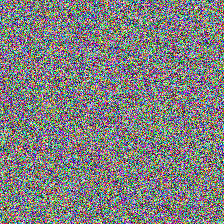

In [31]:
img = vector
Image.fromarray(img.astype(np.uint8))

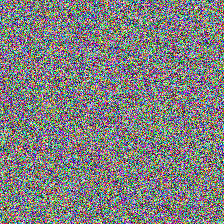

In [37]:
Image.fromarray(vector.astype(np.uint8))